## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [2]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')


In [3]:
print(sys.path)

['/gscratch/matsulab/envs/test-env/lib/python312.zip', '/gscratch/matsulab/envs/test-env/lib/python3.12', '/gscratch/matsulab/envs/test-env/lib/python3.12/lib-dynload', '', '/gscratch/matsulab/envs/test-env/lib/python3.12/site-packages', '../src', '../src']


In [4]:
import jax
import jax.numpy as jnp

# Configure JAX to use only the CPU
# jax.config.update('jax_platform_name', 'cpu') 

print('jax:', jax.__version__)      # 0.7.2
print('devices:', jax.devices())    # [CudaDevice(id=0)]

import jax.experimental.layout as _layout
if not hasattr(_layout, 'DeviceLocalLayout'):
        # Provide a minimal alias so orbax can import function annotations\n",
        _layout.DeviceLocalLayout = _layout.Layout
        print('Patched jax.experimental.layout.DeviceLocalLayout ->', getattr(_layout, 'DeviceLocalLayout'))
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange


jax: 0.7.2
devices: [CudaDevice(id=0)]
Patched jax.experimental.layout.DeviceLocalLayout -> <class 'jax._src.layout.Layout'>


In [5]:
# Utility function to convert GPU/JAX arrays to CPU/NumPy arrays

def to_numpy(tree):
    return jax.tree_util.tree_map(
        lambda x: np.asarray(jax.device_get(x)) if isinstance(x, (jnp.ndarray, np.ndarray)) else x,
        tree,
    )

def as_f32_scalar(x):
    # Make sure to extract as a scalar (float32) even if it's an array/DeviceArray
    return np.asarray(x, dtype=np.float32).reshape(()).item()

In [6]:
GRID_SIZE = 64                  # cryo-ET data will be resampled to GRID_SIZE^3 (64 * 64 * 64)
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Set loss function weights
lambda_1 = 1000000      # Weight for boundary loss (data loss)
lambda_2 = 100           # Weight for physics loss
shape = "bud_04"
sdf_pretrain="sphere"   # sphere or plane

# Initialize JAX random key
key = jax.random.PRNGKey(0)
# 
# Set directory for initial condition
# ckpt_dir = os.path.abspath(f"../outputs/logs/test_phase/snwitch2-2/30000/default")
# ckpt_dir = os.path.abspath(f"../outputs/logs/biconcave/round_1/lambda_5000000_1e-05/checkpoint_30000/")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

# Create train state
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, learning_rate=1e-3, init_ckpt=init_ckpt)
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

#### LOAD MRC DATA #####
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# missing_ratio=0.998
# mrc_file_path = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# flip_ratio=0.2
# mrc_file_path = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# sigma_blur = 5
# mrc_file_path = f"../data/synthetic/biconcave_blur_{str(sigma_blur).replace('.', '')}.mrc"
# num_patch=10
# rad_patch=25
# mrc_file_path = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"

flip_ratio=0.175
# wedge_axis='y'
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

# Training Data
num_collocation = 10000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3


# Training loop
num_steps = 10000
# num_steps = 1000
save_interval = 100


# # temporary 
# binary_mask = jnp.where(cryoET_data > 0.8, 1, 0)
# membrane_indices = jnp.where(binary_mask.ravel() == 1)[0]

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")

# --- keep the same schema for step 0 ---
init_d = initial_loss(state, x_train, cryoET_data)     # Get the dictionary of initial losses
init_total = init_d.get("total_loss", init_d.get("total", init_d.get("loss", 0.0)))
init_data  = init_d.get("data_loss",  init_d.get("data",  0.0))
init_phys  = init_d.get("physics_loss", init_d.get("phys", init_d.get("physics", 0.0)))

payload0 = {
    "state": to_numpy(state),
    "loss": {
        "step":         np.asarray([0], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(init_total)], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(init_data)],  dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(init_phys)],  dtype=np.float32),
    }
}

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    target=payload0,
    step=0,
    overwrite=False,
    keep=NUM_CHECKPOINTS_TO_KEEP,
)


loss_history = []



# for step in range(num_steps):
for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)
    # state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, membrane_indices)

    loss_history.append({
    "step":  step + 1,
    "total_loss":   loss_val,
    "data_loss":    loss_data_val,
    "physics_loss": loss_physics_val
    })

    if (step + 1) % save_interval == 0:
        batched_loss = {
          "step":         np.asarray([e["step"] for e in loss_history], dtype=np.int64),
        "total_loss":   np.asarray([as_f32_scalar(e["total_loss"])   for e in loss_history], dtype=np.float32),
        "data_loss":    np.asarray([as_f32_scalar(e["data_loss"])    for e in loss_history], dtype=np.float32),
        "physics_loss": np.asarray([as_f32_scalar(e["physics_loss"]) for e in loss_history], dtype=np.float32),
    }

        payload = {
            "state": to_numpy(state),  # 항상 CPU NumPy로
            "loss":  batched_loss
        }

        checkpoints.save_checkpoint(
            ckpt_dir=checkpoint_dir,
            target=payload,
            step=step + 1,
            overwrite=False,
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        print(f"Checkpoint saved at step {step+1}")
        loss_history = []


Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 100
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.0
Cryo-ET Data Max: 0.9559755
Cryo-ET Unique Values: [0.0000000e+00 8.9188625e-21 1.7837725e-20 ... 9.4762564e-01 9.5060521e-01
 9.5597547e-01]


  0%|          | 0/10000 [00:00<?, ?it/s]

Checkpoint saved at step 100
Checkpoint saved at step 200
Checkpoint saved at step 300
Checkpoint saved at step 400
Checkpoint saved at step 500
Checkpoint saved at step 600
Checkpoint saved at step 700
Checkpoint saved at step 800
Checkpoint saved at step 900
Checkpoint saved at step 1000
Checkpoint saved at step 1100
Checkpoint saved at step 1200
Checkpoint saved at step 1300
Checkpoint saved at step 1400
Checkpoint saved at step 1500
Checkpoint saved at step 1600
Checkpoint saved at step 1700
Checkpoint saved at step 1800
Checkpoint saved at step 1900
Checkpoint saved at step 2000
Checkpoint saved at step 2100
Checkpoint saved at step 2200
Checkpoint saved at step 2300
Checkpoint saved at step 2400
Checkpoint saved at step 2500
Checkpoint saved at step 2600
Checkpoint saved at step 2700
Checkpoint saved at step 2800
Checkpoint saved at step 2900
Checkpoint saved at step 3000
Checkpoint saved at step 3100
Checkpoint saved at step 3200
Checkpoint saved at step 3300
Checkpoint saved at

### Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/lambda_1000000_100
Resizing MRC data from (128, 128, 128) to (64, 64, 64)


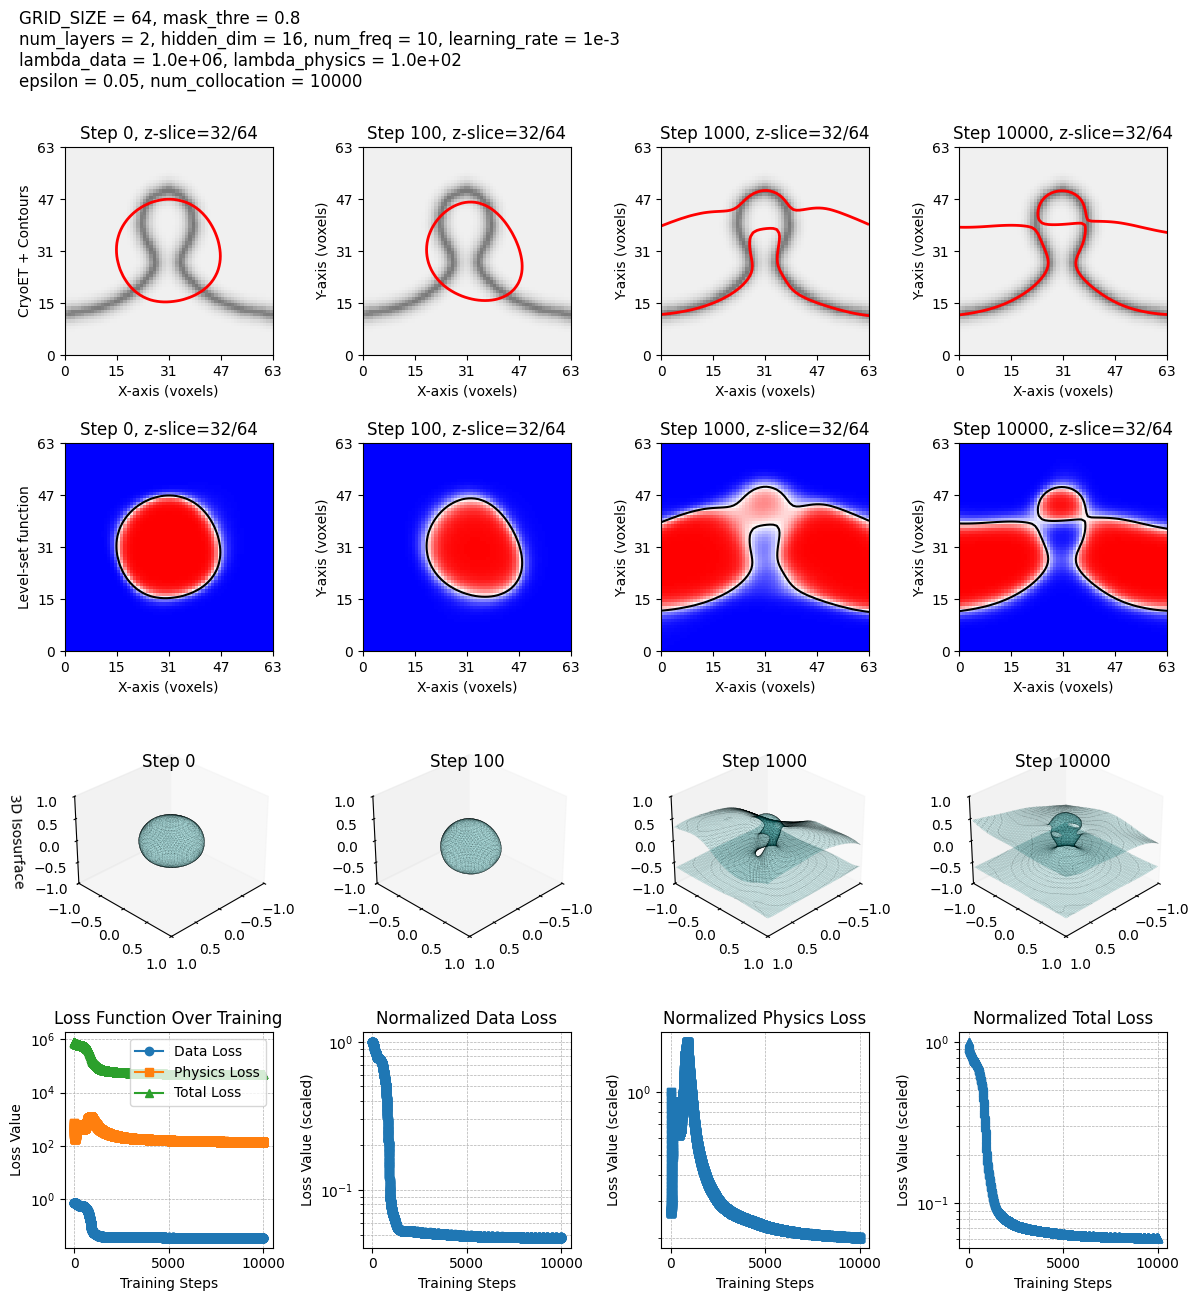

In [8]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 1000000
# lambda_2 = 100
num_collocation = 10000
# num_collocation = 1000
num_layers = 2
# shape = "bud"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_series = list(range(0, 1001, 100))
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    # print(checkpoint_path)
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

TypeError: 'NoneType' object is not iterable

saving step 0


TypeError: 'NoneType' object is not subscriptable

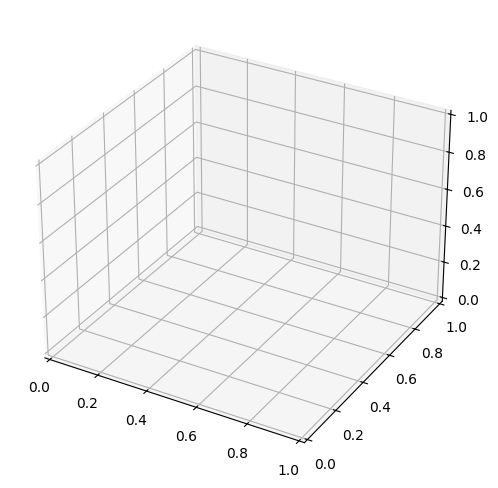

In [13]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re

steps_to_visualize = list(range(0, 30001, 1000))
log_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"frames")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

for step in steps_to_visualize:
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)

In [ ]:
import sys
sys.path.append('../src/pinn')
sys.path.append('../src/data_generation')

%run routine.py